In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
# from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 100) 

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

np.random.seed(42)


In [203]:
import matplotlib.font_manager as fm

plt.style.use('seaborn-v0_8-whitegrid')
font_path = "C:/Windows/Fonts/malgun.ttf"
font = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font
plt.rcParams['axes.unicode_minus'] = False


In [204]:
# 데이터 로드 & 정제

all = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df= all.copy()
# print(df.shape[0], 'rows × ', df.shape[1], 'columns')
# 111495 rows ×  29 columns

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [205]:
# 배송 지연 계산 (핵심 타겟)
# 배송 지연 일수 계산
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

# 결측치 제거 (핵심 칼럼만)
df_analysis = df.copy()
df = df[['delivery_delay_days', 'is_delayed', 'review_score']].dropna()

In [206]:
#극단, 이상치 확인
Q1 = df['delivery_delay_days'].quantile(0.25)
Q3 = df['delivery_delay_days'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
lower_outlier_count = (df['delivery_delay_days'] < lower_bound).sum()

upper_bound = Q3 + 1.5 * IQR
upper_outlier_count = (df['delivery_delay_days'] > upper_bound).sum()

print((df['delivery_delay_days'] < lower_bound).sum()) 
print((df['delivery_delay_days'] > upper_bound).sum())

# Lower: 2123 #전체의 약 2%
# Upper: 2680

2123
2680


In [207]:
#배송지연일 상한선 설정 위한 분포 재확인

#df['delivery_delay_days'].quantile([0.95,0.99,0.999])
# 0.950     3.000
# 0.990    18.000
# 0.999    51.211

#df['delivery_delay_days'].max() 
# #np.int64(188)

In [208]:
#상한선 99.9 결정
q999 = df['delivery_delay_days'].quantile(0.999) 
#len(df) #108790 rows
#df_cut = df[df['delivery_delay_days'] <= q999]
# len(df_cut)  #108681
# 289행 감소 #0.2%

In [209]:
# 상한선, 하한선 도입
# 분포 균형을 위해서 log 도입(0값으로 인해서 log1p)

df = df[(df['delivery_delay_days'] <= q999) & 
            (df['delivery_delay_days'] >= lower_bound)]
df['delay_log'] = np.log1p(df['delivery_delay_days'])

In [210]:
df = df[
    (df['review_score'].notna())].copy()
df.groupby('delivery_delay_days')['review_score'].mean()
df.groupby(pd.cut(df['delivery_delay_days'], 
                  [-10,0,3,7,14,100]))['review_score'].mean()

# delivery_delay_days
# (-10, 0]     4.156442
# (0, 3]       3.231286
# (3, 7]       2.089175
# (7, 14]      1.684377 #7일 확인 필요
# (14, 100]    1.614706

delivery_delay_days
(-10, 0]     4.156442
(0, 3]       3.231286
(3, 7]       2.089175
(7, 14]      1.684377
(14, 100]    1.614706
Name: review_score, dtype: float64

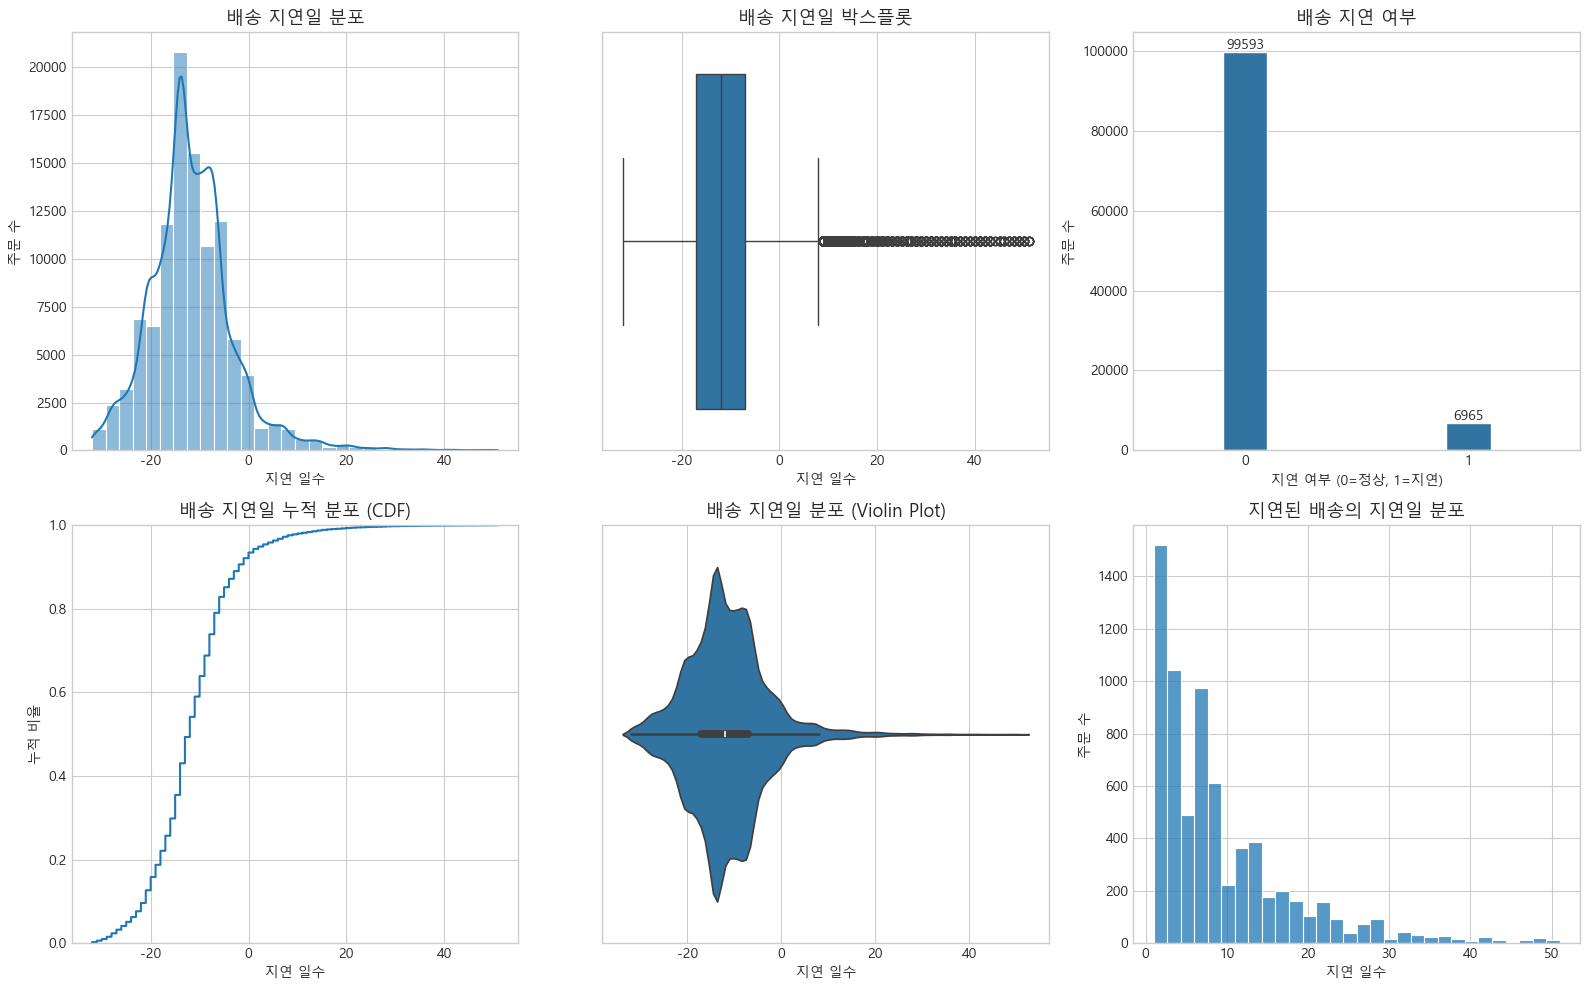

In [211]:
#시각화 확인

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 배송 지연일 분포
sns.histplot(df['delivery_delay_days'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("배송 지연일 분포", fontsize=13)
axes[0,0].set_xlabel("지연 일수")
axes[0,0].set_ylabel("주문 수")

# 박스플롯 (이상치 확인)
sns.boxplot(x=df['delivery_delay_days'], ax=axes[0,1])
axes[0,1].set_title("배송 지연일 박스플롯", fontsize=13)
axes[0,1].set_xlabel("지연 일수")

# 배송 지연 여부 막대그래프
sns.countplot(x='is_delayed', data=df, ax=axes[0,2], width=0.2)
axes[0,2].set_title("배송 지연 여부", fontsize=13)
axes[0,2].set_xlabel("지연 여부 (0=정상, 1=지연)")
axes[0,2].set_ylabel("주문 수")

# bar 값 표시
for p in axes[0,2].patches:
    axes[0,2].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# CDF (누적 분포)
sns.ecdfplot(df['delivery_delay_days'], ax=axes[1,0])
axes[1,0].set_title("배송 지연일 누적 분포 (CDF)", fontsize=13)
axes[1,0].set_xlabel("지연 일수")
axes[1,0].set_ylabel("누적 비율")

# Violin plot
sns.violinplot(x=df['delivery_delay_days'], ax=axes[1,1])
axes[1,1].set_title("배송 지연일 분포 (Violin Plot)", fontsize=13)
axes[1,1].set_xlabel("지연 일수")

# 지연된 배송만 분포
sns.histplot(df[df['is_delayed']==1]['delivery_delay_days'], bins=30, ax=axes[1,2])
axes[1,2].set_title("지연된 배송의 지연일 분포", fontsize=13)
axes[1,2].set_xlabel("지연 일수")
axes[1,2].set_ylabel("주문 수")

plt.tight_layout()
plt.show()

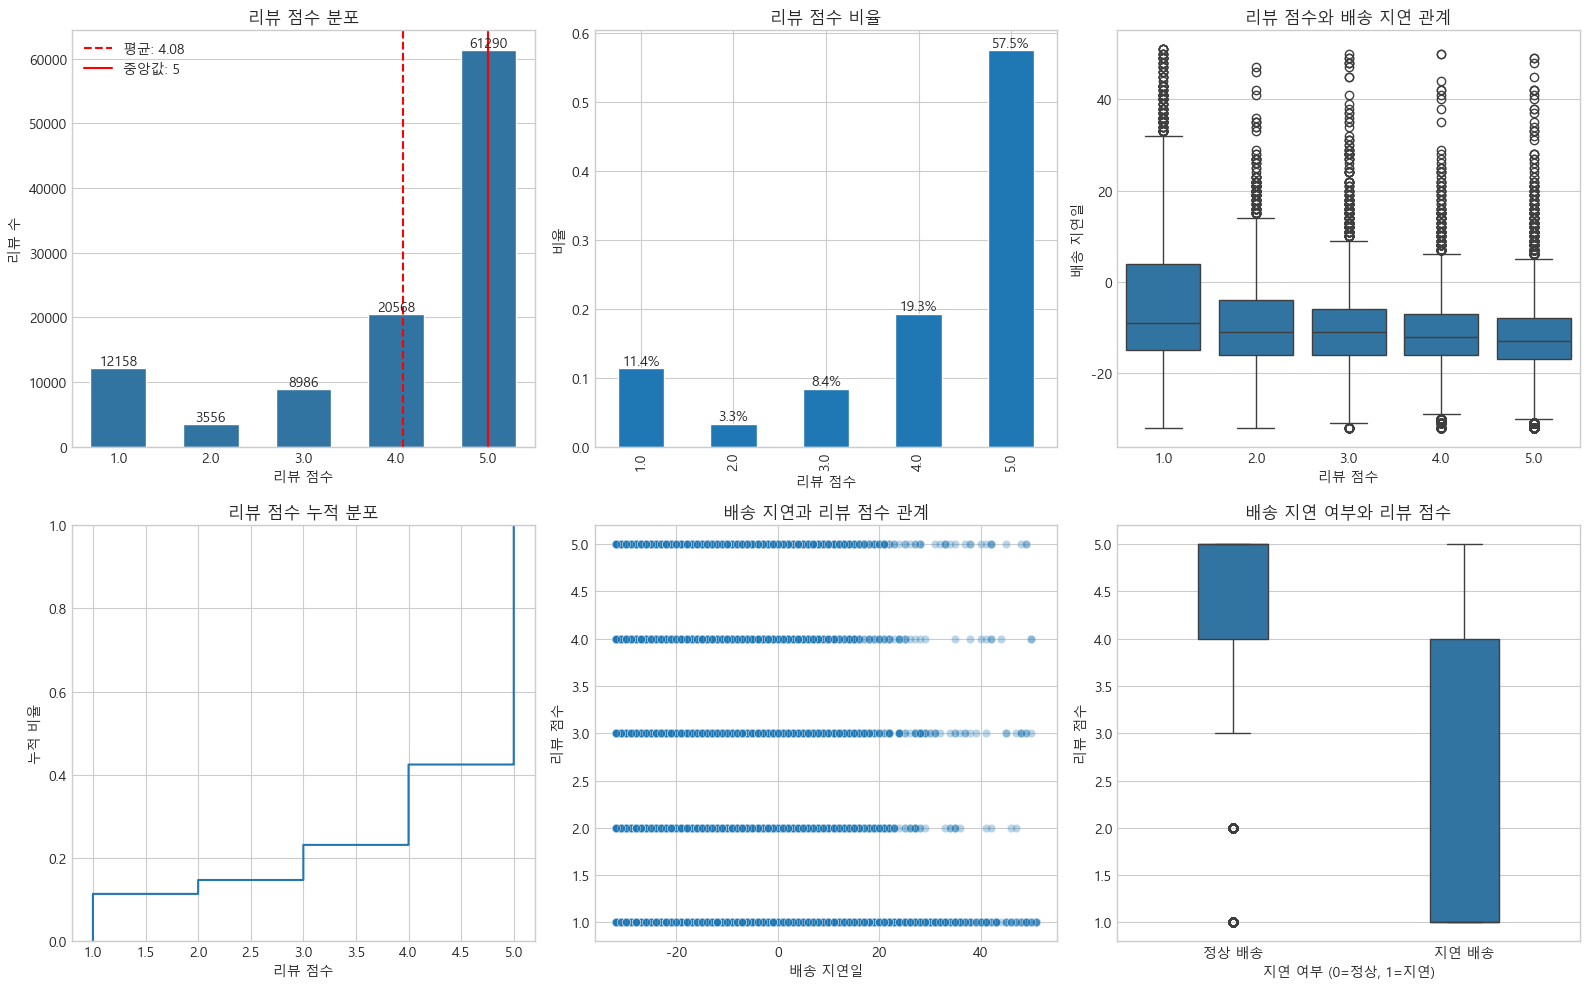

In [212]:
#리뷰 분포

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. 리뷰 점수 분포
mean_score = df['review_score'].mean()
median_score = df['review_score'].median()

sns.countplot(x='review_score', data=df, ax=axes[0,0], width=0.6)

    # 평균 / 중앙값 표시
axes[0,0].axvline(mean_score-1, linestyle='--', color= 'red', label=f'평균: {mean_score:.2f}')
axes[0,0].axvline(median_score-1, linestyle='-', color= 'red', label=f'중앙값: {median_score:.0f}')

axes[0,0].set_title("리뷰 점수 분포")
axes[0,0].set_xlabel("리뷰 점수")
axes[0,0].set_ylabel("리뷰 수")

    # bar 위에 값 표시
for p in axes[0,0].patches:
    axes[0,0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
axes[0,0].legend()

# 2. 리뷰 점수 비율
review_ratio = df['review_score'].value_counts(normalize=True).sort_index()
bars = review_ratio.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("리뷰 점수 비율")
axes[0,1].set_xlabel("리뷰 점수")
axes[0,1].set_ylabel("비율")

    # bar 위에 값 표시
for i, v in enumerate(review_ratio):
    axes[0,1].text(i, v + 0.005, f"{v*100:.1f}%", ha='center', fontsize=10)

# 3. 배송 지연 & 리뷰 점수
sns.boxplot(x='review_score', y='delivery_delay_days', data=df, ax=axes[0,2])
axes[0,2].set_title("리뷰 점수와 배송 지연 관계")
axes[0,2].set_xlabel("리뷰 점수")
axes[0,2].set_ylabel("배송 지연일")

# 4. 리뷰 점수 누적 분포
sns.ecdfplot(df['review_score'], ax=axes[1,0])
axes[1,0].set_title("리뷰 점수 누적 분포")
axes[1,0].set_xlabel("리뷰 점수")
axes[1,0].set_ylabel("누적 비율")

# 5. 배송 지연 & 리뷰 Scatter
sns.scatterplot(x='delivery_delay_days', y='review_score', data=df, alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("배송 지연과 리뷰 점수 관계")
axes[1,1].set_xlabel("배송 지연일")
axes[1,1].set_ylabel("리뷰 점수")

# 6. 배송 지연 여부 & 리뷰 점수
sns.boxplot(x='is_delayed', y='review_score', data=df, ax=axes[1,2], width=0.3)

axes[1,2].set_title("배송 지연 여부와 리뷰 점수")
axes[1,2].set_xlabel("지연 여부 (0=정상, 1=지연)")
axes[1,2].set_ylabel("리뷰 점수")
axes[1,2].set_xticklabels(['정상 배송', '지연 배송'])

plt.tight_layout()
plt.show()

In [213]:
# 배송지연 & 고객만족도 상관분석 

# 상관분석 / 연속형과 ordinal 데이터의 상관 분석 _모호해서 둘 다 진행해봄
# 극단치가 있고, 비정규 가능성이 크며, 리뷰가 ordinal 이기 때문에 스피어만 결과를 더 중요하게 볼 것
pearson_corr, pearson_pval = pearsonr(df['delivery_delay_days'], 
                                       df['review_score'])
spearman_corr, spearman_pval = spearmanr(df['delivery_delay_days'], 
                                          df['review_score'])

print(f"Pearson: {pearson_corr:.4f} (p-value: {pearson_pval:.2e})")
print(f"Spearman: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})")

#결과
# 상관계수:
# Pearson: -0.2619 (p-value: 0.00e+00)
# Spearman: -0.1573 (p-value: 0.00e+00)

#p값 해석
        # pearson_pval < 0.05: 유의미     
        # 음의 상관관계가 있다는 것이 통계적으로 강하게 유의미한 것으로 보임
#상관계수 해석
        # 피어슨 -0.26 약한 음의 상관 / 배송 지연일이 증가할수록 리뷰 점수가 약하게 감소하는 경향이 있음
        # 스피어만 -0.15 약한 음의 상관 / 배송 지연 순위가 증가할수록 리뷰 점수 순위가 약하게 감소하는 경향이 있음


Pearson: -0.2619 (p-value: 0.00e+00)
Spearman: -0.1573 (p-value: 0.00e+00)


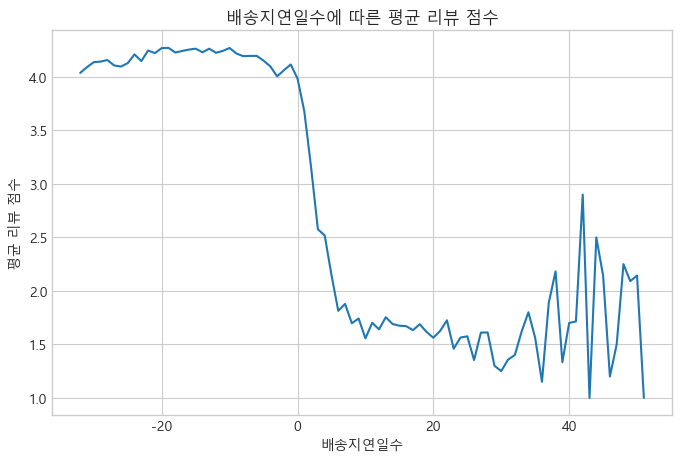

In [214]:
delay_review = df.groupby('delivery_delay_days')['review_score'].mean()

plt.figure(figsize=(8,5))

plt.plot(delay_review.index, delay_review.values)

plt.xlabel("배송지연일수")
plt.ylabel("평균 리뷰 점수")
plt.title("배송지연일수에 따른 평균 리뷰 점수")

plt.show()

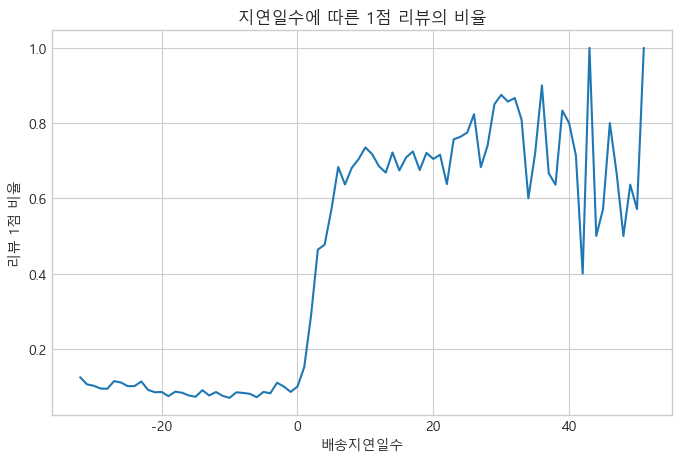

In [215]:
df['bad_review'] = (df['review_score'] == 1).astype(int)
bad_ratio = df.groupby('delivery_delay_days')['bad_review'].mean()

plt.figure(figsize=(8,5))
plt.plot(bad_ratio.index, bad_ratio.values)

plt.xlabel("배송지연일수")
plt.ylabel("리뷰 1점 비율")
plt.title("지연일수에 따른 1점 리뷰의 비율")

plt.show()

## 배송지연된 주문건수에만 대한 분석

In [216]:
late_df = df[df['delivery_delay_days'] > 0].copy()
late_df.shape

(6965, 5)

In [217]:
late_df['review_score'].value_counts()

review_score
1.0    3809
5.0    1143
3.0     740
4.0     678
2.0     595
Name: count, dtype: int64

In [218]:
late_df['review_score'].describe()

count    6965.000000
mean        2.246375
std         1.568154
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max         5.000000
Name: review_score, dtype: float64

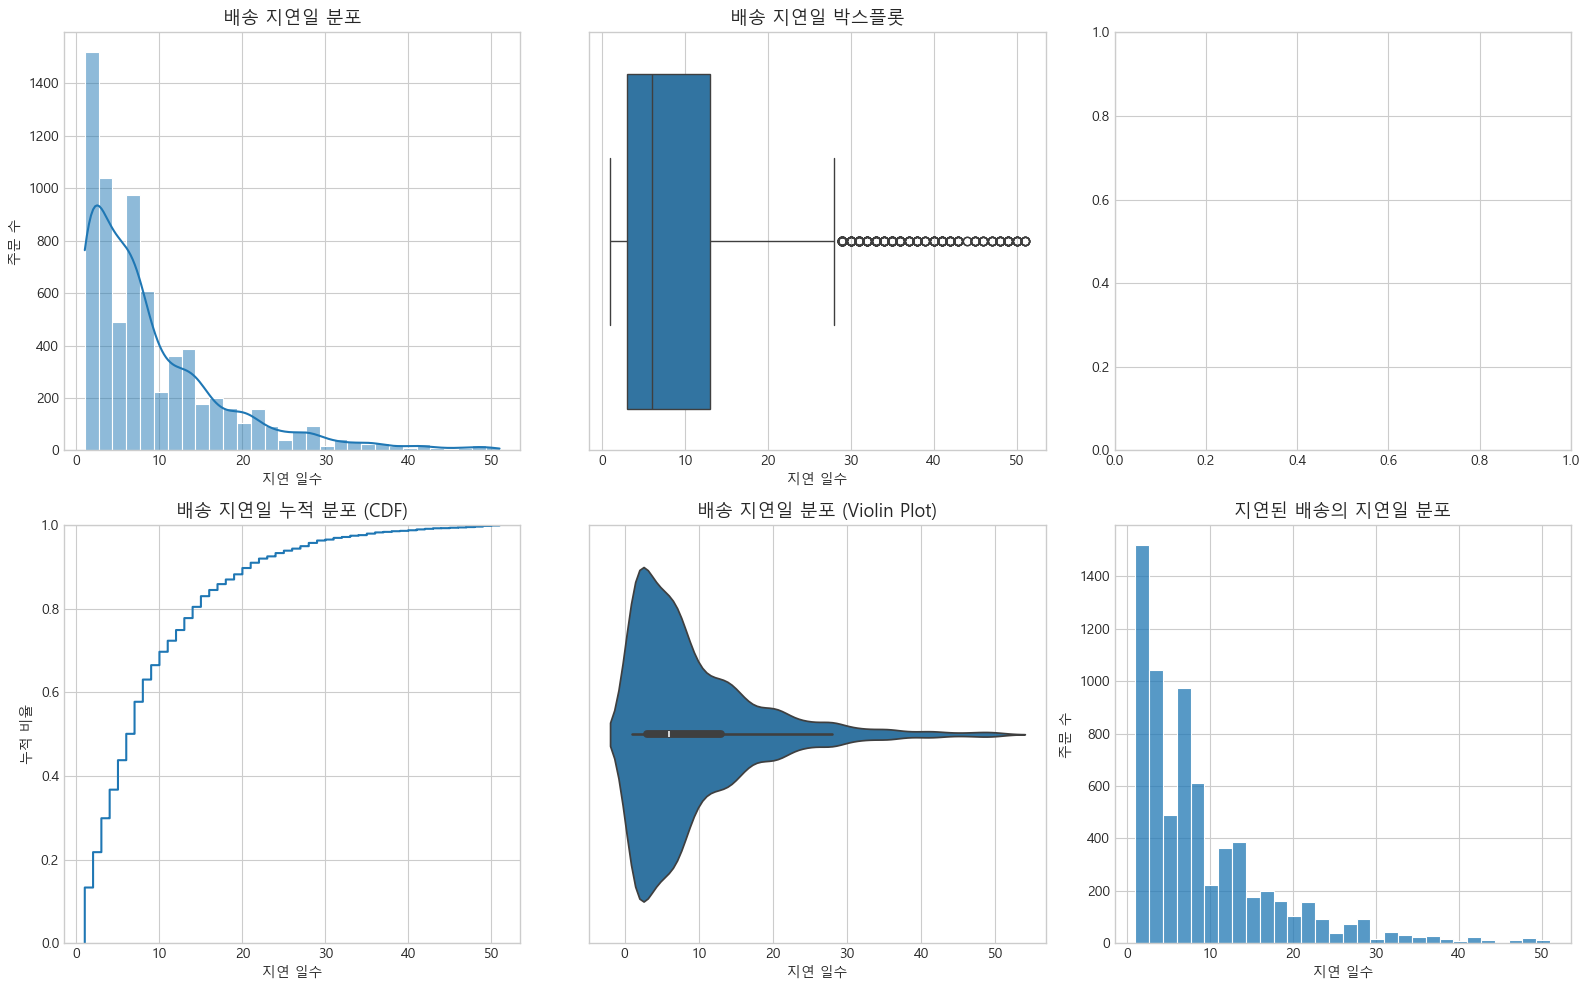

In [219]:
#시각화 확인

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 배송 지연일 분포
sns.histplot(late_df['delivery_delay_days'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("배송 지연일 분포", fontsize=13)
axes[0,0].set_xlabel("지연 일수")
axes[0,0].set_ylabel("주문 수")

# 박스플롯 (이상치 확인)
sns.boxplot(x=late_df['delivery_delay_days'], ax=axes[0,1])
axes[0,1].set_title("배송 지연일 박스플롯", fontsize=13)
axes[0,1].set_xlabel("지연 일수")


# bar 값 표시
for p in axes[0,2].patches:
    axes[0,2].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# CDF (누적 분포)
sns.ecdfplot(late_df['delivery_delay_days'], ax=axes[1,0])
axes[1,0].set_title("배송 지연일 누적 분포 (CDF)", fontsize=13)
axes[1,0].set_xlabel("지연 일수")
axes[1,0].set_ylabel("누적 비율")

# Violin plot
sns.violinplot(x=late_df['delivery_delay_days'], ax=axes[1,1])
axes[1,1].set_title("배송 지연일 분포 (Violin Plot)", fontsize=13)
axes[1,1].set_xlabel("지연 일수")

# 지연된 배송만 분포
sns.histplot(late_df[late_df['is_delayed']==1]['delivery_delay_days'], bins=30, ax=axes[1,2])
axes[1,2].set_title("지연된 배송의 지연일 분포", fontsize=13)
axes[1,2].set_xlabel("지연 일수")
axes[1,2].set_ylabel("주문 수")

plt.tight_layout()
plt.show()

In [220]:
# 배송지연 & 고객만족도 상관분석 

# 상관분석 / 연속형과 ordinal 데이터의 상관 분석 _모호해서 둘 다 진행해봄
# 극단치가 있고, 비정규 가능성이 크며, 리뷰가 ordinal 이기 때문에 스피어만 결과를 더 중요하게 볼 것
pearson_corr, pearson_pval = pearsonr(late_df['delivery_delay_days'], 
                                       late_df['review_score'])
spearman_corr, spearman_pval = spearmanr(late_df['delivery_delay_days'], 
                                          late_df['review_score'])

print(f"Pearson: {pearson_corr:.4f} (p-value: {pearson_pval:.2e})")
print(f"Spearman: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})")

#결과
# 상관계수:
#    - Pearson: -0.3030 (p-value: 7.57e-148
#    - Spearman: -0.4075 (p-value: 1.02e-278)
#p값 해석
        # pearson_pval < 0.05: 유의미     
        # 음의 상관관계가 있다는 것이 통계적으로 강하게 유의미한 것으로 보임
#상관계수 해석
        # 피어슨 -0.30 약한 음의 상관 / 배송 지연일이 증가할수록 리뷰 점수가 감소하는 경향이 있음
        # 스피어만 -0.4 중간 정도의 음의 상관 / 배송 지연 순위가 증가할수록 리뷰 점수 순위가 어느 정도 감소하는 경향이 있음
    # |피어슨| < |스피어만| : 선형 관계는 약하나, 단조 관계는 어느 정도 있음
    #                      : 배송지연일 증가 ~ 리뷰 감소 경향은 맞음
    #                      : 그러나 일정 비율로 감소X, 비선형 관계(단계형 등)일 가능성 있음 

Pearson: -0.3030 (p-value: 7.57e-148)
Spearman: -0.4150 (p-value: 4.07e-288)


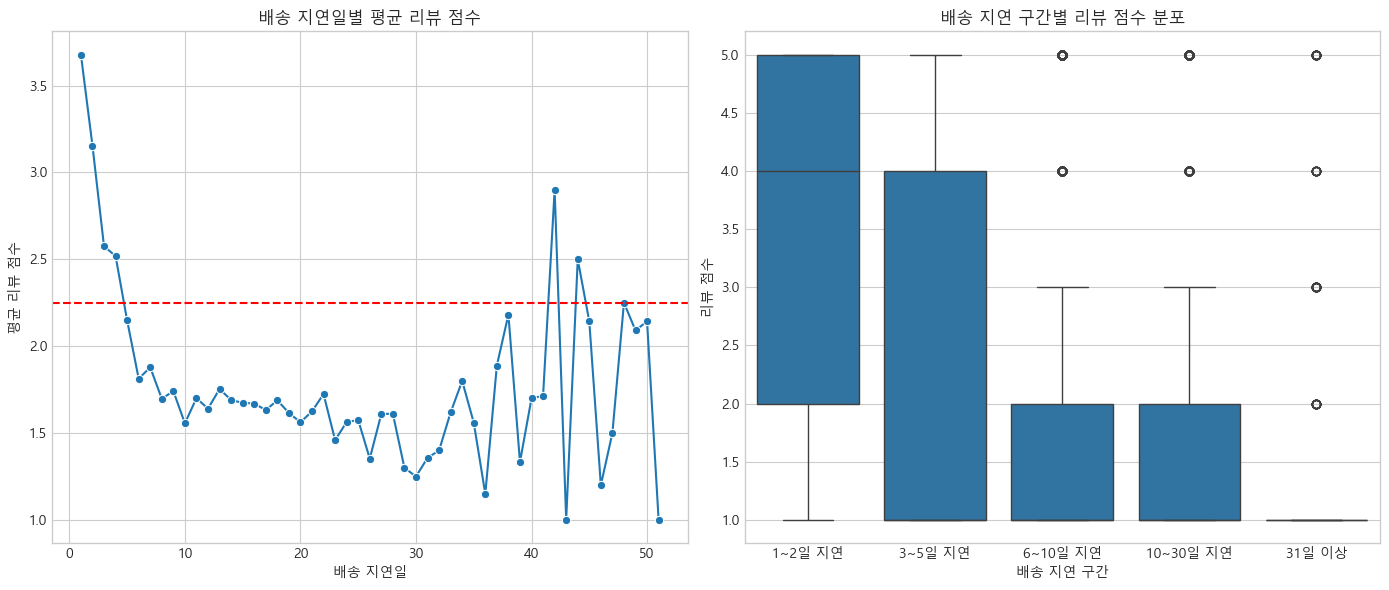

In [221]:
# 배송 지연일별 평균 리뷰
delay_review = late_df.groupby('delivery_delay_days')['review_score'].mean().reset_index()

# 배송 지연 구간 생성
bins = [1,3,6,11,30,np.inf]

labels = [
    '1~2일 지연',
    '3~5일 지연',
    '6~10일 지연',
    '10~30일 지연',
    '31일 이상'
]

late_df['delay_group'] = pd.cut(
    late_df['delivery_delay_days'],
    bins=bins,
    labels=labels,
    right=False
)

# 시각화
fig, axes = plt.subplots(1,2, figsize=(14,6))

# 1. 배송 지연일별 평균 리뷰
sns.lineplot(
    data=delay_review,
    x='delivery_delay_days',
    y='review_score',
    marker='o',
    ax=axes[0]
)

axes[0].axhline(late_df['review_score'].mean(), linestyle='--', color='red')
axes[0].set_title("배송 지연일별 평균 리뷰 점수")
axes[0].set_xlabel("배송 지연일")
axes[0].set_ylabel("평균 리뷰 점수")

# 2. 배송 지연 구간별 리뷰
sns.boxplot(
    data=late_df,
    x='delay_group',
    y='review_score',
    ax=axes[1]
)

axes[1].set_title("배송 지연 구간별 리뷰 점수 분포")
axes[1].set_xlabel("배송 지연 구간")
axes[1].set_ylabel("리뷰 점수")

plt.tight_layout()
plt.show()


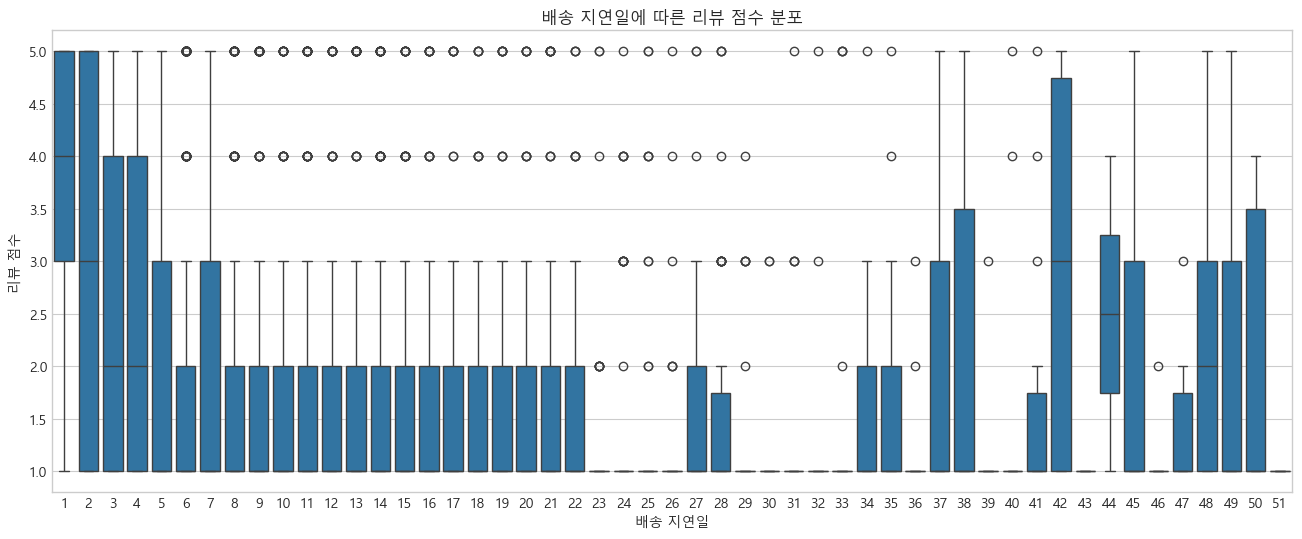

In [222]:
# 배송 지연일 & 리뷰 분포 

plt.figure(figsize=(16,6))
sns.boxplot(
    data=late_df,
    x='delivery_delay_days',
    y='review_score'
)

plt.title("배송 지연일에 따른 리뷰 점수 분포")
plt.xlabel("배송 지연일")
plt.ylabel("리뷰 점수")

plt.show()


In [223]:
print(late_df['delay_group'].value_counts())

delay_group
10~30일 지연    1853
6~10일 지연     1806
3~5일 지연      1532
1~2일 지연      1519
31일 이상        255
Name: count, dtype: int64


In [224]:
from scipy import stats
import scikit_posthocs as sp

#Kruskal-Wallis 검정
df_test = late_df.dropna(subset=['delay_group','review_score'])

groups = [
    df_test[df_test['delay_group']==label]['review_score']
    for label in labels
]

h_stat, p_val = stats.kruskal(*groups)

print("Kruskal-Wallis H:", h_stat)
print("p-value:", p_val)

# Kruskal-Wallis H: 1373.9506677899442
# p-value: 3.075927914833485e-296
# 귀무가설: 모든 그룹 분포 동일 #기각
# 대립가설: 적어도 하나 다름

Kruskal-Wallis H: 1374.2153575738423
p-value: 2.6951505752229025e-296


In [225]:
# Dunn post-hoc test
# Kruskal-Wallis 검정에서 유의미한 차이 O

posthoc = sp.posthoc_dunn(df_test, val_col='review_score', group_col='delay_group', p_adjust='bonferroni')
print(posthoc)
print()

# p값이 0.05 미만인 쌍
significant_pairs = []
for i in range(len(posthoc.columns)):
    for j in range(i+1, len(posthoc.columns)):
        if posthoc.iloc[i, j] < 0.05:
            group_i = posthoc.columns[i]
            group_j = posthoc.columns[j]
            p_value = posthoc.iloc[i, j]
            significant_pairs.append((group_i, group_j, p_value))
            print(f"{group_i} vs {group_j}: p = {p_value:.4f}")

if not significant_pairs:
    print("유의미한 차이 있는 쌍이 없다.")

# 유의미한 차이 있는 그룹 쌍:
# 1~2일 지연 vs 3~5일 지연: p = 0.0000
# 1~2일 지연 vs 6~10일 지연: p = 0.0000
# 1~2일 지연 vs 10~30일 지연: p = 0.0000
# 1~2일 지연 vs 31일 이상: p = 0.0000
# 3~5일 지연 vs 6~10일 지연: p = 0.0000
# 3~5일 지연 vs 10~30일 지연: p = 0.0000
# 3~5일 지연 vs 31일 이상: p = 0.0000


                 1~2일 지연       3~5일 지연       6~10일 지연      10~30일 지연  \
1~2일 지연     1.000000e+00  1.201968e-73  3.239007e-205  5.952960e-237   
3~5일 지연     1.201968e-73  1.000000e+00   2.076862e-30   1.288528e-42   
6~10일 지연   3.239007e-205  2.076862e-30   1.000000e+00   2.668111e-01   
10~30일 지연  5.952960e-237  1.288528e-42   2.668111e-01   1.000000e+00   
31일 이상      4.996748e-67  1.962595e-13   9.217468e-01   1.000000e+00   

                 31일 이상  
1~2일 지연    4.996748e-67  
3~5일 지연    1.962595e-13  
6~10일 지연   9.217468e-01  
10~30일 지연  1.000000e+00  
31일 이상     1.000000e+00  

1~2일 지연 vs 3~5일 지연: p = 0.0000
1~2일 지연 vs 6~10일 지연: p = 0.0000
1~2일 지연 vs 10~30일 지연: p = 0.0000
1~2일 지연 vs 31일 이상: p = 0.0000
3~5일 지연 vs 6~10일 지연: p = 0.0000
3~5일 지연 vs 10~30일 지연: p = 0.0000
3~5일 지연 vs 31일 이상: p = 0.0000


In [226]:
#t-test 비교
from scipy import stats

results = []

for threshold in range(1, 15): 
    group1 = late_df[late_df['delivery_delay_days'] <= threshold]['review_score'] # 1~N일
    group2 = late_df[late_df['delivery_delay_days'] > threshold]['review_score']  # N+일
    
    if len(group1) > 1 and len(group2) > 1:
        t_stat, p_val = stats.ttest_ind(group1, group2)
        results.append({
            'threshold': threshold,
            'group1_mean': group1.mean(),
            'group2_mean': group2.mean(),
            'mean_diff': abs(group1.mean() - group2.mean()),
            'p_val': p_val
        })

results_df = pd.DataFrame(results)
results_df
#결과해석 : p값이 0.05 미만이면 배송지연이 " "일 이상이면 리뷰 점수가 유의미하게 떨어진다는 의미!

,threshold,group1_mean,group2_mean,mean_diff,p_val
0,1,3.678495,2.025684,1.652811,2.462744e-210
1,2,3.475313,1.903599,1.571714,1.640461e-286
2,3,3.231286,1.825855,1.405431,2.886897e-281
3,4,3.098828,1.750965,1.347863,2.659779e-287
4,5,2.945919,1.701073,1.244846,3.001604e-257
5,6,2.803438,1.686906,1.116532,3.118270e-207
6,7,2.680666,1.652159,1.028507,6.524823e-170
7,8,2.597861,1.645663,0.952198,5.707380e-138
8,9,2.553517,1.635779,0.917739,3.770043e-122
9,10,2.507721,1.644213,0.863508,3.674318e-102


In [227]:
# 최적 임계값 찾기 (2가지 방법)

# 평균 차이가 가장 큰 임계값
best_mean_diff = results_df.loc[results_df['mean_diff'].idxmax()]
# print(f"임계값: {int(best_mean_diff['threshold'])}일")
# print(f"평균 차이: {best_mean_diff['mean_diff']:.3f}점")
# print(f"p값: {best_mean_diff['p_val']:.2e}")
# print('')

# p값이 가장 작은 임계값 (가장 유의미)
best_p_val = results_df.loc[results_df['p_val'].idxmin()]
# print(f"임계값: {int(best_p_val['threshold'])}일")
# print(f"평균 차이: {best_p_val['mean_diff']:.3f}점")
# print(f"p값: {best_p_val['p_val']:.2e}")


#======================================================================================

# 결과
# 평균차가 가장 큰 임계값
# 임계값: 1일
# 평균 차이: 1.653점
# p값: 2.46e-210

# p값이 가장 작은 임계값
# 임계값: 4일
# 평균 차이: 1.348점
# p값: 2.66e-287

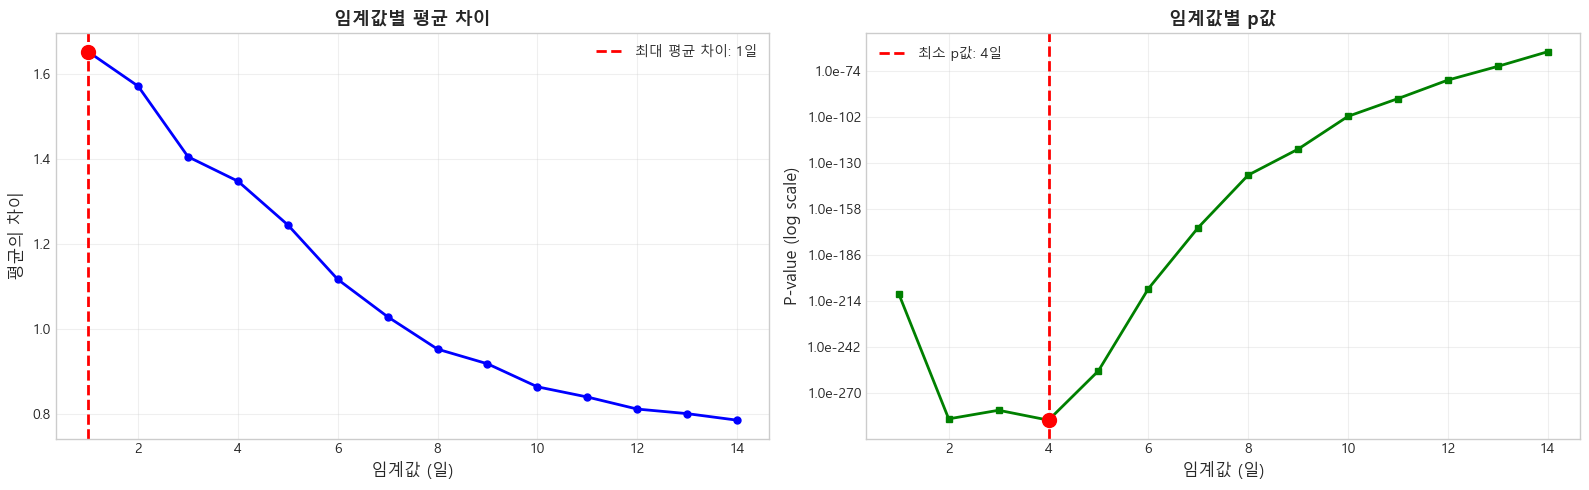

In [228]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

def format_sci(x, pos):
    """지수 표기법을 마이너스 기호 없이 포맷"""
    if x == 0:
        return '0'
    s = f'{x:.1e}'
    parts = s.split('e')
    mantissa = parts[0]
    exponent = parts[1]
    exp_num = int(exponent)
    return f'{float(mantissa):.1f}e{exp_num}'



# 비교 시각화
best_mean_diff = results_df.loc[results_df['mean_diff'].idxmax()]
threshold_1 = int(best_mean_diff['threshold'])
mean_diff_1 = best_mean_diff['mean_diff']
p_val_1 = best_mean_diff['p_val']

best_p_val = results_df.loc[results_df['p_val'].idxmin()]
threshold_2 = int(best_p_val['threshold'])
mean_diff_2 = best_p_val['mean_diff']
p_val_2 = best_p_val['p_val']


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 평균 차이 변화
axes[0].plot(results_df['threshold'], results_df['mean_diff'], marker='o', linewidth=2, markersize=5, color='blue')
axes[0].axvline(threshold_1, color='red', linestyle='--', linewidth=2, label=f'최대 평균 차이: {threshold_1}일')
axes[0].scatter([threshold_1], [mean_diff_1], color='red', s=100, zorder=5)
axes[0].set_xlabel('임계값 (일)', fontsize=12)
axes[0].set_ylabel('평균의 차이', fontsize=12)
axes[0].set_title('임계값별 평균 차이', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# p값 변화
axes[1].semilogy(results_df['threshold'], results_df['p_val'], marker='s', linewidth=2, markersize=5, color='green')
axes[1].axvline(threshold_2, color='red', linestyle='--', linewidth=2, label=f'최소 p값: {threshold_2}일')
axes[1].scatter([threshold_2], [p_val_2], color='red', s=100, zorder=5)
axes[1].set_xlabel('임계값 (일)', fontsize=12)
axes[1].set_ylabel('P-value (log scale)', fontsize=12)
axes[1].set_title('임계값별 p값', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, which='both')
axes[1].yaxis.set_major_formatter(FuncFormatter(format_sci))
axes[1].legend()

plt.tight_layout()
plt.show()



In [229]:
# 임계값 최종 결정(p값이 가장 작은 임계값)
best_threshold = int(best_p_val['threshold'])
best_threshold

4

In [230]:
#Cohen's d (Effect size)

def cohens_d(x,y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(
        ((nx-1)*np.var(x,ddof=1) + (ny-1)*np.var(y,ddof=1)) /
        (nx+ny-2)
    )

    d = (np.mean(x) - np.mean(y)) / pooled_std
    return d

results = []

for k in range(0,15):

    g1 = late_df[late_df['delivery_delay_days'] <= k]['review_score']
    g2 = late_df[late_df['delivery_delay_days'] > k]['review_score']

    if len(g1) < 30 or len(g2) < 30:
        continue

    d = cohens_d(g1,g2)
    results.append((k,d))

effect_df = pd.DataFrame(results, columns=['threshold','cohens_d'])

# print(effect_df)
#     threshold  cohens_d
# 0           1  1.128965
# 1           2  1.100936
# 2           3  0.982754
# 3           4  0.944382
# 4           5  0.863584
# 5           6  0.761874
# 6           7  0.693211
# 7           8  0.635044
# 8           9  0.608874
# 9          10  0.569128
# 10         11  0.551338
# 11         12  0.530704
# 12         13  0.522232
# 13         14  0.510668

# 초기 지연에 민감

In [231]:
# Elbow Method 

inertias = []
threshold_list = np.arange(0, 76, 1)  #임의 지정

#분산 계산
for threshold in threshold_list:
    group1 = late_df[late_df['delivery_delay_days'] <= threshold]['review_score']
    group2 = late_df[late_df['delivery_delay_days'] > threshold]['review_score']
    
    if len(group1) > 1 and len(group2) > 1:
        inertia = group1.var() * len(group1) + group2.var() * len(group2)
        inertias.append(inertia)
        
        #print(f"임계값 {threshold:.1f}일: 분산 = {inertia:.2f}")
    else:
        inertias.append(np.nan)
inertias = np.array(inertias)

#기울기 변화 
# 1차 미분 (기울기)
slopes = np.diff(inertias)

# 2차 미분 (기울기의 변화)
second_derivative = np.diff(slopes)

#elbow 찾기
# 기울기가 가장 급격하게 변하는 지점이자 분산이 가장 크게 줄어드는 지점
elbow_idx = np.nanargmax(np.abs(second_derivative)) + 1
elbow_threshold = threshold_list[elbow_idx]

print(f"최적 임계값 (Elbow): {elbow_threshold:.1f}일")
print(f"(최대 2차 미분 값: {np.abs(second_derivative[elbow_idx-1]):.2f})")

# 두 그룹 정보 출력
group1_elbow = late_df[late_df['delivery_delay_days'] <= elbow_threshold]['review_score']
group2_elbow = late_df[late_df['delivery_delay_days'] > elbow_threshold]['review_score']

# 결과
# 최적 임계값 (Elbow): 2.0일
# (최대 2차 미분 값: 782.02)

최적 임계값 (Elbow): 2.0일
(최대 2차 미분 값: 782.02)


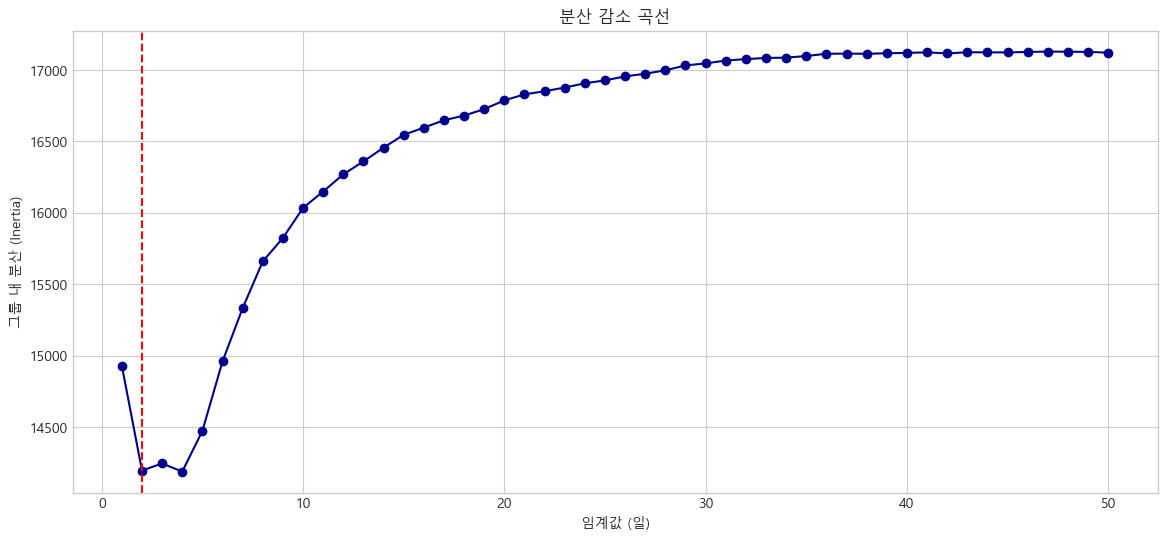

In [232]:
# 시각화 _분산 곡선 (Inertia)

plt.figure(figsize=(14,6))

plt.plot(
    threshold_list,
    inertias,
    marker='o',
    color='darkblue'
)

plt.axvline(
    x=elbow_threshold,
    color='red',
    linestyle='--'
)

plt.xlabel('임계값 (일)')
plt.ylabel('그룹 내 분산 (Inertia)')
plt.title('분산 감소 곡선')

plt.show()


# 최적 임계값: 2일
# 2일을 기준으로 그룹을 나누면 그룹 내 분산이 가장 크게 줄어듦
# 즉, 두 그룹이 가장 잘 분리됨
# 배송 지연 2일 기준으로 리뷰 평가 패턴이 달라질 가능성이 있음


In [233]:
#Decision Tree 임계값 탐색
X = late_df[['delivery_delay_days']]
y = late_df['review_score']

tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X, y)

# print(tree.tree_.threshold)
# print(tree.tree_.n_node_samples)
# print(tree.tree_.value)

# 결과
# 트리 임계값: [ 4.5  2.5 -2.  -2.   5.5 -2.  -2. ]
# 각 노드의 샘플 수: [6965 2560 1519 1041 4405  491 3914]
# 각 노드의 값: [[[2.24637473]]

# 결과
# 총 임계값 개수: 3
# 임계값 범위: 2.50 ~ 5.50
#   임계값 1: 4.50
#   임계값 2: 2.50
#   임계값 3: 5.50

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf